In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
import pandas as pd
import os

file_path = '/content/gdrive/My Drive/DAP391m/cleaned_healthcare_stroke_data.csv'

try:
    df = pd.read_csv(file_path)
    display(df.head())
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp tại đường dẫn: {file_path}")
    print("Đang kiểm tra nội dung thư mục...")
    my_drive_path = '/content/gdrive/My Drive' # Corrected path for My Drive
    if os.path.exists(my_drive_path):
        print(f"Nội dung của '{my_drive_path}':")
        for item in os.listdir(my_drive_path):
            print(item)
    else:
        print(f"Thư mục 'My Drive' không tồn tại ở {my_drive_path}. Vui lòng kiểm tra lại việc mount Google Drive.")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,log_avg_glucose_level,log_bmi
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly smoked,1,5.436731,3.627004
1,51676,female,61.0,0,0,yes,self-employed,rural,202.21,28.1,never smoked,1,5.314240,3.370738
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never smoked,1,4.672081,3.511545
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1,5.148831,3.566712
4,1665,female,79.0,1,0,yes,self-employed,rural,174.12,24.0,never smoked,1,5.165471,3.218876


PREPROCESSING

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load data nếu chưa có
# df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# ===== CLEAN DATA =====

# drop id nếu có
if "id" in df.columns:
    df = df.drop(columns=["id"])

# ✅ drop gender == Other (quan trọng)
if "gender" in df.columns:
    df = df[df["gender"] != "Other"].copy()

# ===== SPLIT X / y =====
X = df.drop(columns=["stroke"])
y = df["stroke"]

# ===== TRAIN TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ===== PRINT CHECK =====
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Stroke rate train:", y_train.mean(), " test:", y_test.mean())

Train: (4088, 12)  Test: (1022, 12)
Stroke rate train: 0.04867906066536203  test: 0.04892367906066536


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Nếu bạn có log features thì CHỐT 1 phiên bản:
# Option A: dùng original
numeric_features = ["age", "log_avg_glucose_level", "log_bmi", "hypertension", "heart_disease"]

# Option B: dùng log (nếu bạn đã tạo log_avg_glucose_level, log_bmi)
# numeric_features = ["age", "log_avg_glucose_level", "log_bmi", "hypertension", "heart_disease"]

categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Num features:", len(feature_names))
print(feature_names)

Processed train shape: (4088, 16)
Processed test shape: (1022, 16)
Num features: 16
['num__age' 'num__log_avg_glucose_level' 'num__log_bmi'
 'num__hypertension' 'num__heart_disease' 'cat__gender_male'
 'cat__gender_other' 'cat__ever_married_yes' 'cat__work_type_govt_job'
 'cat__work_type_never_worked' 'cat__work_type_private'
 'cat__work_type_self-employed' 'cat__Residence_type_urban'
 'cat__smoking_status_never smoked' 'cat__smoking_status_smokes'
 'cat__smoking_status_unknown']


In [7]:
import pandas as pd

# fit trên train, transform train/test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# lấy tên cột sau preprocessing
feature_names = preprocessor.get_feature_names_out()

# đổi sang DataFrame để xem
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

print(X_train_processed_df.head())

      num__age  num__log_avg_glucose_level  num__log_bmi  num__hypertension  \
845   0.205661                   -0.984906      0.650718          -0.327962   
3744 -1.254901                    0.583751     -1.091728          -0.327962   
4183  1.046590                    0.302459     -0.442863          -0.327962   
3409  0.028623                   -1.140017     -0.458244          -0.327962   
284  -1.299160                   -0.507003      0.471863          -0.327962   

      num__heart_disease  cat__gender_male  cat__gender_other  \
845            -0.239061               0.0                0.0   
3744           -0.239061               1.0                0.0   
4183           -0.239061               0.0                0.0   
3409           -0.239061               1.0                0.0   
284            -0.239061               1.0                0.0   

      cat__ever_married_yes  cat__work_type_govt_job  \
845                     1.0                      0.0   
3744                  

In [8]:
X_train_processed = preprocessor.fit_transform(X_train)
print("Processed train shape:", X_train_processed.shape)

Processed train shape: (4088, 16)


TRAIN

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'log_avg_glucose_level',
                                                   'log_bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

Imbalance : cost sensitive learning
weight= n_sample/n_class * n_sample_class

In [10]:
from sklearn.metrics import roc_auc_score

y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc)

ROC-AUC: 0.8430041152263374


In [39]:
from sklearn.model_selection import GridSearchCV, cross_validate

# L1 model
logreg_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear"
    ))
])

# Tune hyperparameter C cho L1
param_grid_l1 = {
    "model__C": [0.001, 0.01, 0.1, 1, 10]
}

grid_l1 = GridSearchCV(
    estimator=logreg_l1,
    param_grid=param_grid_l1,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_l1.fit(X_train, y_train)


# Gán lại biến cũ để code phía dưới không phải đổi
logreg_l1 = grid_l1.best_estimator_

cv_results_l1 = cross_validate(
    logreg_l1,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("LogReg L1 ROC-AUC:", cv_results_l1["test_roc_auc"].mean())
print("LogReg L1 PR-AUC:", cv_results_l1["test_pr_auc"].mean())
print("LogReg L1 F1-Score:", cv_results_l1["test_f1"].mean())

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


LogReg L1 ROC-AUC: 0.8393432157828045
LogReg L1 PR-AUC: 0.19058106128585162
LogReg L1 F1-Score: 0.22880175760885146


In [56]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_validate

# Pipeline SVC Linear
svc_linear = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVC(
        kernel="linear",
        class_weight="balanced",
        probability=True
    ))
])

# Tune hyperparameter C
param_grid_svc_linear = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid_svc_linear = GridSearchCV(
    estimator=svc_linear,
    param_grid=param_grid_svc_linear,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_svc_linear.fit(X_train, y_train)

#  In best params (cái bạn muốn)
print("Best SVC Linear params:", grid_svc_linear.best_params_)
print("Best SVC Linear CV PR-AUC:", grid_svc_linear.best_score_)

# Gán lại biến cũ
svc_linear = grid_svc_linear.best_estimator_

cv_results_svc_linear = cross_validate(
    svc_linear,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Output giữ nguyên format cũ
print("SVC Linear ROC-AUC:", cv_results_svc_linear["test_roc_auc"].mean())
print("SVC Linear PR-AUC:", cv_results_svc_linear["test_pr_auc"].mean())
print("SVC Linear F1-Score:", cv_results_svc_linear["test_f1"].mean())

SVC Linear Baseline ROC-AUC: 0.4736732001642028
SVC Linear Baseline PR-AUC: 0.04748982886794541
SVC Linear Baseline F1-Score: 0.0


In [59]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Pipeline
logreg_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=5000
    ))
])

# Grid search
param_grid_l2 = [
    {
        "model__solver": ["liblinear", "lbfgs"],
        "model__C": [0.001, 0.01, 0.1, 1, 3, 10, 30, 100],
        "model__class_weight": [None, "balanced"]
    }
]

grid_l2 = GridSearchCV(
    estimator=logreg_l2,
    param_grid=param_grid_l2,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_l2.fit(X_train, y_train)

print("Best L2 params:", grid_l2.best_params_)
print("Best L2 CV PR-AUC:", grid_l2.best_score_)

# gán lại như code cũ
logreg_l2 = grid_l2.best_estimator_

# ===== giữ nguyên cross_validate như bạn =====
cv_results_l2 = cross_validate(
    logreg_l2,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("LogReg L2 ROC-AUC:", cv_results_l2["test_roc_auc"].mean())
print("LogReg L2 PR-AUC:", cv_results_l2["test_pr_auc"].mean())
print("LogReg L2 F1-Score:", cv_results_l2["test_f1"].mean())

Best L2 params: {'model__C': 3, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best L2 CV PR-AUC: 0.19278413723115534


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


LogReg L2 ROC-AUC: 0.8387667978863351
LogReg L2 PR-AUC: 0.19278413723115534
LogReg L2 F1-Score: 0.0


In [41]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_validate

svc_rbf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True
    ))
])

param_grid_svc_rbf = {
    "model__C": [0.1, 1, 10, 50],
    "model__gamma": ["scale", "auto", 0.01, 0.1]
}

grid_svc_rbf = GridSearchCV(
    estimator=svc_rbf,
    param_grid=param_grid_svc_rbf,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_svc_rbf.fit(X_train, y_train)

# In best params
print("Best SVC RBF params:", grid_svc_rbf.best_params_)
print("Best SVC RBF CV PR-AUC:", grid_svc_rbf.best_score_)

# Gán lại biến cũ để code dưới không phải đổi
svc_rbf = grid_svc_rbf.best_estimator_

cv_results_svc_rbf = cross_validate(
    svc_rbf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Giữ output kiểu cũ
print("SVC RBF ROC-AUC:", cv_results_svc_rbf["test_roc_auc"].mean())
print("SVC RBF PR-AUC:", cv_results_svc_rbf["test_pr_auc"].mean())
print("SVC RBF F1-Score:", cv_results_svc_rbf["test_f1"].mean())

Best SVC RBF params: {'model__C': 50, 'model__gamma': 0.01}
Best SVC RBF CV PR-AUC: 0.19692108160344665


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


SVC RBF ROC-AUC: 0.8144961219447081
SVC RBF PR-AUC: 0.19692108160344665
SVC RBF F1-Score: 0.20179113103427887


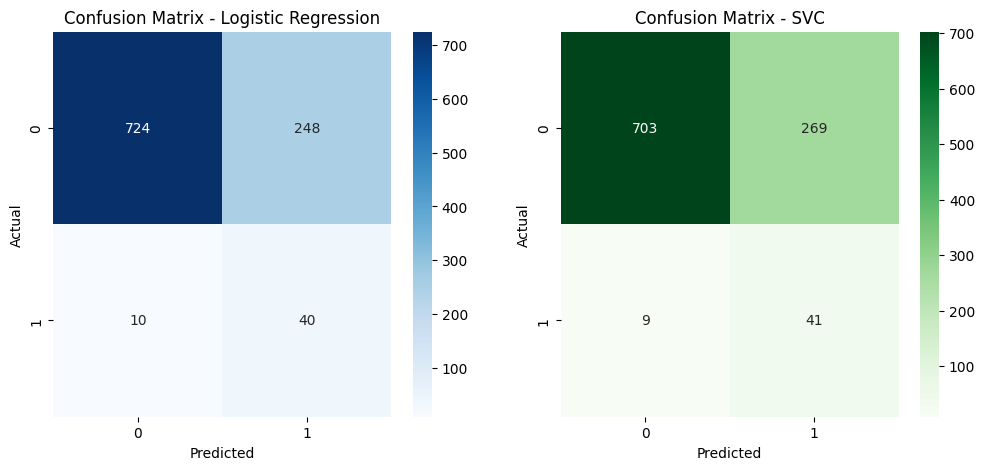

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Ensure models are fitted before prediction
# logreg_l2 was fitted in previous cells (e.g., z4uu3FT4yydq) on the entire X_train, y_train
# We need to fit svc_linear here as it was only cross-validated previously.
svc_linear.fit(X_train, y_train)

# Get predictions for Logistic Regression
y_pred_lr = logreg_l2.predict(X_test)

# Get predictions for SVC
y_pred_svc = svc_linear.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vẽ cho Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Vẽ cho SVC
cm_svc = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - SVC')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Create the output directory if it doesn't exist
output_dir = '../outputs/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'confusion_matrices_default.png'), dpi=300, bbox_inches='tight')
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# dùng đúng model cuối của bạn
model = logreg_l2   # hoặc model bạn muốn đánh giá

# xác suất lớp 1
y_prob = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.4, 0.01)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

df_thresh = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

print(df_thresh.head(10))

best_threshold = df_thresh.loc[0, "threshold"]
print("Best threshold:", best_threshold)
print("Best F1:", df_thresh.loc[0, "f1"])
print("Best Precision:", df_thresh.loc[0, "precision"])
print("Best Recall:", df_thresh.loc[0, "recall"])

   threshold  precision  recall        f1
0       0.40   0.117978    0.84  0.206897
1       0.39   0.115702    0.84  0.203390
2       0.38   0.113821    0.84  0.200477
3       0.37   0.110818    0.84  0.195804
4       0.36   0.107969    0.84  0.191344
5       0.35   0.105793    0.84  0.187919
6       0.34   0.104738    0.84  0.186253
7       0.33   0.101942    0.84  0.181818
8       0.32   0.100000    0.84  0.178723
9       0.31   0.098131    0.84  0.175732
Best threshold: 0.4000000000000001
Best F1: 0.20689655172413793
Best Precision: 0.11797752808988764
Best Recall: 0.84


In [17]:
from sklearn.metrics import roc_curve
import numpy as np

y_proba_test = logreg_l2.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print("Best threshold by Youden =", best_threshold)

Best threshold by Youden = 0.6252125718446527


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

youden_threshold = 0.6252125718446527

y_pred_youden = (y_proba_test >= youden_threshold).astype(int)

print(f"Threshold = {youden_threshold:.4f}")
print(confusion_matrix(y_test, y_pred_youden))
print(classification_report(y_test, y_pred_youden))

Threshold = 0.6252
[[796 176]
 [ 11  39]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       972
           1       0.18      0.78      0.29        50

    accuracy                           0.82      1022
   macro avg       0.58      0.80      0.59      1022
weighted avg       0.95      0.82      0.87      1022



In [19]:
y_pred_best = (y_proba_test >= best_threshold).astype(int)

print(f"Threshold = {best_threshold}")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Threshold = 0.6252125718446527
[[796 176]
 [ 11  39]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       972
           1       0.18      0.78      0.29        50

    accuracy                           0.82      1022
   macro avg       0.58      0.80      0.59      1022
weighted avg       0.95      0.82      0.87      1022



In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# threshold mặc định
y_pred_05 = (y_proba_test >= 0.50).astype(int)

print("Threshold = 0.5")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05))

# thử threshold thấp hơn
y_pred_03 = (y_proba_test >= 0.3).astype(int)

print("Threshold = 0.3")
print(confusion_matrix(y_test, y_pred_03))
print(classification_report(y_test, y_pred_03))

Threshold = 0.5
[[724 248]
 [ 10  40]]
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022

Threshold = 0.3
[[579 393]
 [  8  42]]
              precision    recall  f1-score   support

           0       0.99      0.60      0.74       972
           1       0.10      0.84      0.17        50

    accuracy                           0.61      1022
   macro avg       0.54      0.72      0.46      1022
weighted avg       0.94      0.61      0.71      1022



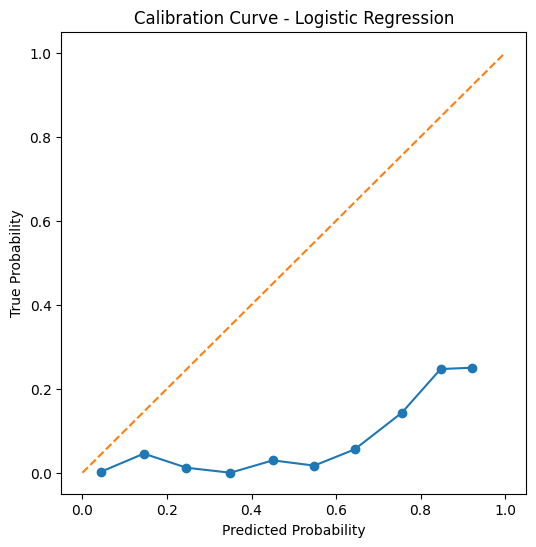

Brier Score: 0.1679419901084123


In [21]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Dùng xác suất từ LogReg
prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve - Logistic Regression")
plt.show()

print("Brier Score:", brier_score_loss(y_test, y_proba_test))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Sigmoid Brier: 0.040827954402894086
Sigmoid ROC-AUC: 0.8431893004115226
Sigmoid PR-AUC: 0.26759163853429696
Isotonic Brier: 0.04079735912781219
Isotonic ROC-AUC: 0.8420164609053498
Isotonic PR-AUC: 0.2691125452970349


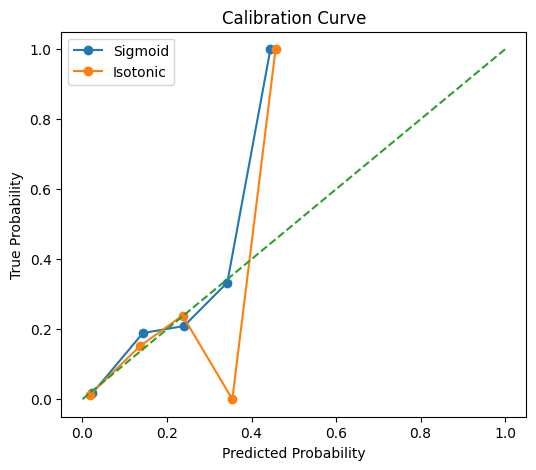

In [22]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Calibrate
cal_sigmoid = CalibratedClassifierCV(logreg_l2, method="sigmoid", cv=5)
cal_sigmoid.fit(X_train, y_train)

cal_isotonic = CalibratedClassifierCV(logreg_l2, method="isotonic", cv=5)
cal_isotonic.fit(X_train, y_train)

# Predict probabilities
y_proba_sigmoid = cal_sigmoid.predict_proba(X_test)[:, 1]
y_proba_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]

# Metrics
print("Sigmoid Brier:", brier_score_loss(y_test, y_proba_sigmoid))
print("Sigmoid ROC-AUC:", roc_auc_score(y_test, y_proba_sigmoid))
print("Sigmoid PR-AUC:", average_precision_score(y_test, y_proba_sigmoid))

print("Isotonic Brier:", brier_score_loss(y_test, y_proba_isotonic))
print("Isotonic ROC-AUC:", roc_auc_score(y_test, y_proba_isotonic))
print("Isotonic PR-AUC:", average_precision_score(y_test, y_proba_isotonic))

# Calibration curves
prob_true_s, prob_pred_s = calibration_curve(y_test, y_proba_sigmoid, n_bins=10)
prob_true_i, prob_pred_i = calibration_curve(y_test, y_proba_isotonic, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred_s, prob_true_s, marker='o', label='Sigmoid')
plt.plot(prob_pred_i, prob_true_i, marker='o', label='Isotonic')
plt.plot([0,1], [0,1], '--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [62]:
import numpy as np
import pandas as pd

# Get coefficients from the Logistic Regression model (which is the 'model' step in the pipeline)
coefficients = logreg_l2.named_steps['model'].coef_[0]

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for coefficients and feature names
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Calculate Odds Ratios
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

# Sort by absolute coefficient value to see most impactful features
coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).reset_index(drop=True)

display(coef_df.head(10))

,feature,coefficient,odds_ratio,abs_coefficient
0,num__age,1.678573,5.357904,1.678573
1,cat__work_type_self-employed,-0.853050,0.426113,0.853050
2,cat__work_type_govt_job,-0.613266,0.541579,0.613266
3,cat__work_type_private,-0.567923,0.566701,0.567923
4,cat__ever_married_yes,-0.302045,0.739305,0.302045
5,cat__smoking_status_never smoked,-0.238574,0.787751,0.238574
6,num__log_avg_glucose_level,0.170880,1.186348,0.170880
7,cat__smoking_status_unknown,-0.170724,0.843054,0.170724
8,cat__work_type_never_worked,-0.158038,0.853817,0.158038
9,num__hypertension,0.137042,1.146876,0.137042


,feature,coefficient,odds_ratio,abs_coefficient
0,num__age,1.678573,5.357904,1.678573
1,num__log_avg_glucose_level,0.170880,1.186348,0.170880
2,num__hypertension,0.137042,1.146876,0.137042
3,cat__smoking_status_smokes,0.096372,1.101168,0.096372
4,cat__Residence_type_urban,0.066066,1.068297,0.066066
5,cat__gender_male,0.052780,1.054197,0.052780
6,num__heart_disease,0.048623,1.049824,0.048623
7,num__log_bmi,0.035200,1.035827,0.035200


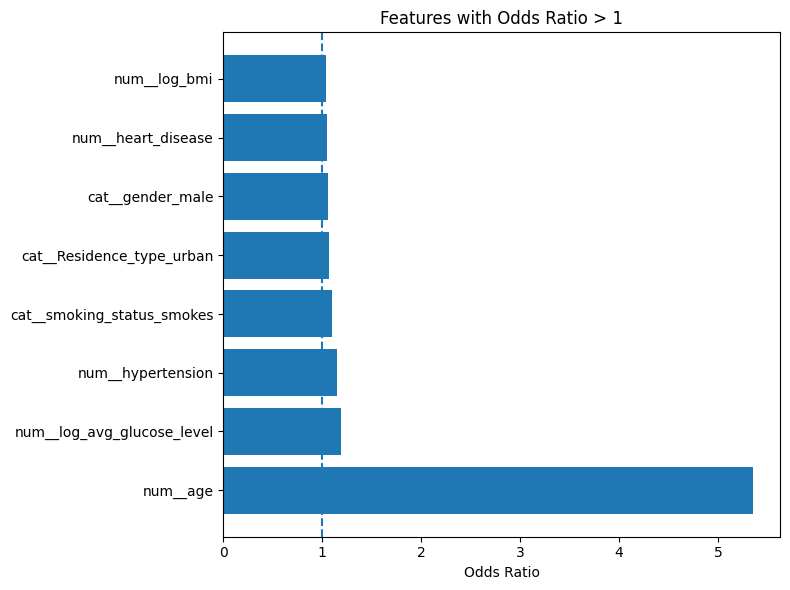

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Lấy coefficients từ Logistic Regression trong pipeline
coefficients = logreg_l2.named_steps['model'].coef_[0]

# 2. Lấy tên feature sau preprocessing
feature_names = preprocessor.get_feature_names_out()

# 3. Tạo DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# 4. Tính Odds Ratio
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

# 5. Lấy độ lớn ảnh hưởng
coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])

# 6. Chỉ giữ feature có Odds Ratio > 1
coef_df = coef_df[coef_df['odds_ratio'] > 1]

# 7. Sort theo mức ảnh hưởng
coef_df = coef_df.sort_values(by='odds_ratio', ascending=False).reset_index(drop=True)

# 8. Hiển thị tất cả feature thỏa điều kiện
display(coef_df)

# 9. Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.barh(coef_df['feature'], coef_df['odds_ratio'])
plt.axvline(x=1, linestyle='--')
plt.xlabel("Odds Ratio")
plt.title("Features with Odds Ratio > 1")
plt.tight_layout()
plt.show()

### Giải thích Odds Ratio:

*   **Odds Ratio (OR) > 1**: Nghĩa là khi biến độc lập tăng 1 đơn vị (hoặc chuyển từ nhóm tham chiếu sang nhóm này đối với biến phân loại), thì xác suất xảy ra biến phụ thuộc (đột quỵ) tăng lên OR lần, giữ các yếu tố khác không đổi.
*   **Odds Ratio (OR) < 1**: Nghĩa là khi biến độc lập tăng 1 đơn vị, thì xác suất xảy ra biến phụ thuộc (đột quỵ) giảm đi OR lần (hoặc 1/OR lần). Ví dụ, nếu OR = 0.5, nghĩa là xác suất giảm đi một nửa.
*   **Odds Ratio (OR) = 1**: Nghĩa là biến độc lập không có tác động lên xác suất xảy ra biến phụ thuộc.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

dummy = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

cv_results_dummy = cross_validate(
    dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Majority ROC-AUC:", cv_results_dummy["test_roc_auc"].mean())
print("Majority PR-AUC:", cv_results_dummy["test_pr_auc"].mean())
print("Majority F1-Score:", cv_results_dummy["test_f1"].mean())

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Majority ROC-AUC: 0.5
Majority PR-AUC: 0.0486788985883712
Majority F1-Score: 0.0


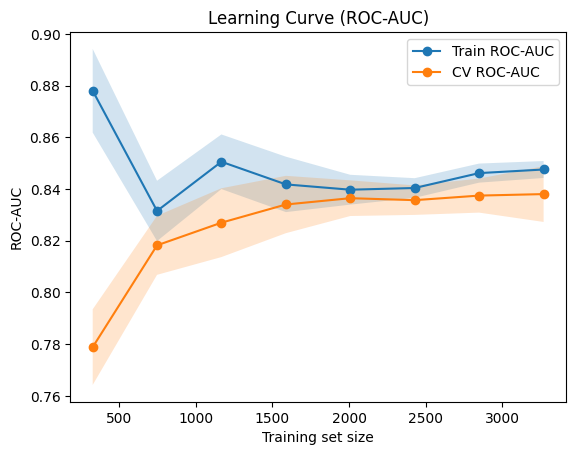

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# dùng model bạn chọn: logreg_l2 (Pipeline preprocess+LogReg)
train_sizes, train_scores, val_scores = learning_curve(
    logreg_l2,
    X_train, y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.plot(train_sizes, train_mean, marker='o', label="Train ROC-AUC")
plt.plot(train_sizes, val_mean, marker='o', label="CV ROC-AUC")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve (ROC-AUC)")
plt.legend()
plt.show()

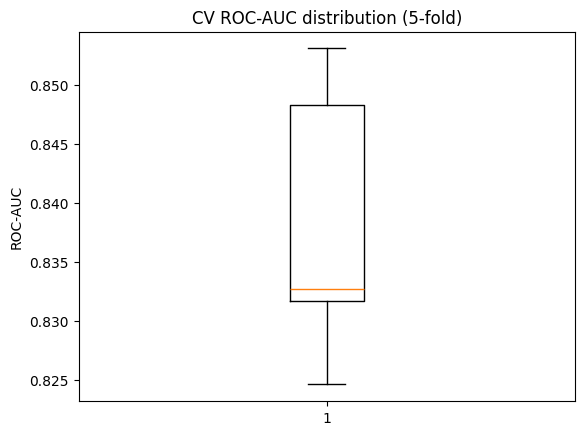

CV ROC-AUC mean±std: 0.8380590171657009 ± 0.010789542891141342


In [26]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logreg_l2, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

plt.boxplot(scores)
plt.ylabel("ROC-AUC")
plt.title("CV ROC-AUC distribution (5-fold)")
plt.show()

print("CV ROC-AUC mean±std:", scores.mean(), "±", scores.std())

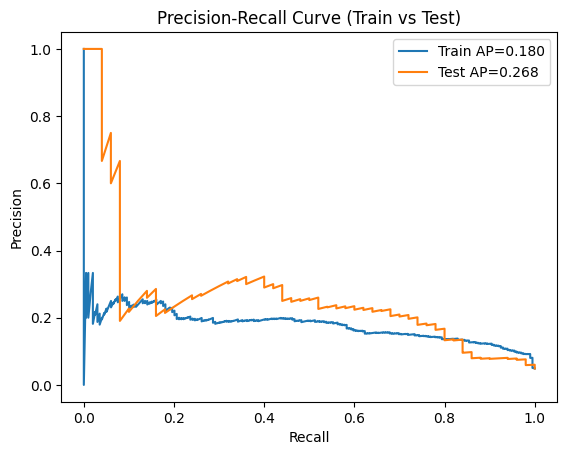

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# fit trên train
logreg_l2.fit(X_train, y_train)

# proba train/test
p_train = logreg_l2.predict_proba(X_train)[:,1]
p_test  = logreg_l2.predict_proba(X_test)[:,1]

prec_tr, rec_tr, _ = precision_recall_curve(y_train, p_train)
prec_te, rec_te, _ = precision_recall_curve(y_test,  p_test)

ap_tr = average_precision_score(y_train, p_train)
ap_te = average_precision_score(y_test,  p_test)

import matplotlib.pyplot as plt
plt.plot(rec_tr, prec_tr, label=f"Train AP={ap_tr:.3f}")
plt.plot(rec_te, prec_te, label=f"Test AP={ap_te:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Train vs Test)")
plt.legend()
plt.show()

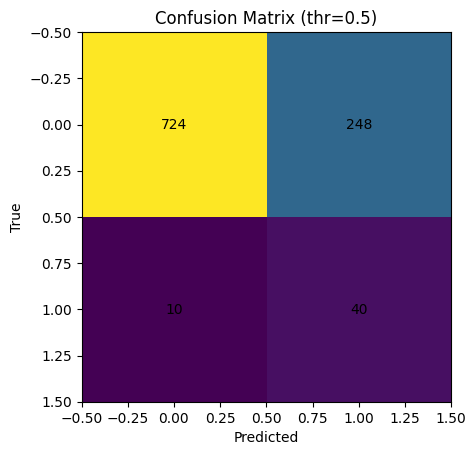

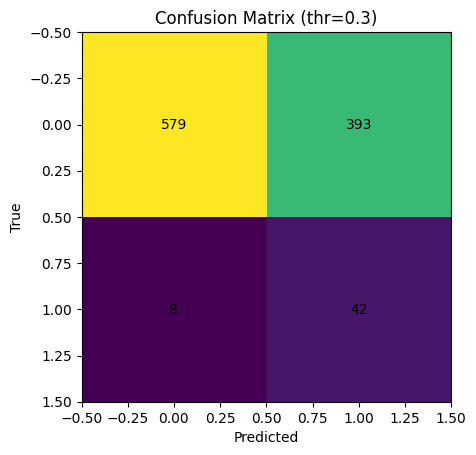

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_proba, thr, title):
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.show()

y_proba_test = logreg_l2.predict_proba(X_test)[:,1]
plot_cm(y_test, y_proba_test, 0.5, "Confusion Matrix (thr=0.5)")
plot_cm(y_test, y_proba_test, 0.3, "Confusion Matrix (thr=0.3)")

In [48]:
results_f1 = []

# Logistic Regression (L2)
results_f1.append({
    "Model": "LogReg (L2)",
    "F1-Score": f"{cv_results_l2['test_f1'].mean():.4f} ± {cv_results_l2['test_f1'].std():.4f}"
})

# SVC Linear
results_f1.append({
    "Model": "SVC (Linear)",
    "F1-Score": f"{cv_results_svc_linear['test_f1'].mean():.4f} ± {cv_results_svc_linear['test_f1'].std():.4f}"
})

# SVC RBF
results_f1.append({
    "Model": "SVC (RBF)",
    "F1-Score": f"{cv_results_svc_rbf['test_f1'].mean():.4f} ± {cv_results_svc_rbf['test_f1'].std():.4f}"
})

df_f1 = pd.DataFrame(results_f1)
df_f1

,Model,F1-Score
0,LogReg (L2),0.2305 ± 0.0117
1,SVC (Linear),0.2208 ± 0.0106
2,SVC (RBF),0.2018 ± 0.0152


In [49]:
import pandas as pd

results_summary = []

# Baseline (Majority class)
results_summary.append({
    "Model": "Majority class",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_dummy['test_roc_auc'].mean():.3f} \u00b1 {cv_results_dummy['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_dummy['test_pr_auc'].mean():.3f} \u00b1 {cv_results_dummy['test_pr_auc'].std():.3f}"
})

# Logistic Regression L2
results_summary.append({
    "Model": "Logistic Regression (L2)",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_l2['test_roc_auc'].mean():.3f} \u00b1 {cv_results_l2['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_l2['test_pr_auc'].mean():.3f} \u00b1 {cv_results_l2['test_pr_auc'].std():.3f}"
})

# Logistic Regression L1
results_summary.append({
    "Model": "Logistic Regression (L1)",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_l1['test_roc_auc'].mean():.3f} \u00b1 {cv_results_l1['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_l1['test_pr_auc'].mean():.3f} \u00b1 {cv_results_l1['test_pr_auc'].std():.3f}"
})

# SVC Linear
results_summary.append({
    "Model": "SVC Linear",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_svc_linear['test_roc_auc'].mean():.3f} \u00b1 {cv_results_svc_linear['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_svc_linear['test_pr_auc'].mean():.3f} \u00b1 {cv_results_svc_linear['test_pr_auc'].std():.3f}"
})

# SVC RBF
results_summary.append({
    "Model": "SVC RBF",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_svc_rbf['test_roc_auc'].mean():.3f} \u00b1 {cv_results_svc_rbf['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_svc_rbf['test_pr_auc'].mean():.3f} \u00b1 {cv_results_svc_rbf['test_pr_auc'].std():.3f}"
})

df_summary = pd.DataFrame(results_summary)
display(df_summary)

,Model,Split/CV,ROC-AUC,PR-AUC
0,Majority class,Stratified CV,0.500 ± 0.000,0.049 ± 0.000
1,Logistic Regression (L2),Stratified CV,0.838 ± 0.011,0.191 ± 0.039
2,Logistic Regression (L1),Stratified CV,0.839 ± 0.013,0.191 ± 0.039
3,SVC Linear,Stratified CV,0.839 ± 0.010,0.196 ± 0.037
4,SVC RBF,Stratified CV,0.814 ± 0.018,0.197 ± 0.040


In [46]:
import pandas as pd

results = []

# Baseline
results.append({
    "Model": "Majority class",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_dummy['test_roc_auc'].mean():.3f} ± {cv_results_dummy['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_dummy['test_pr_auc'].mean():.3f} ± {cv_results_dummy['test_pr_auc'].std():.3f}"
})

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_l2['test_roc_auc'].mean():.3f} ± {cv_results_l2['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_l2['test_pr_auc'].mean():.3f} ± {cv_results_l2['test_pr_auc'].std():.3f}"
})

# SVC Linear (using cv_results_svc_linear as it was successfully computed)
results.append({
    "Model": "SVC Linear",
    "Split/CV": "Stratified CV",
    "ROC-AUC": f"{cv_results_svc_linear['test_roc_auc'].mean():.3f} ± {cv_results_svc_linear['test_roc_auc'].std():.3f}",
    "PR-AUC": f"{cv_results_svc_linear['test_pr_auc'].mean():.3f} ± {cv_results_svc_linear['test_pr_auc'].std():.3f}"
})

df_results = pd.DataFrame(results)

df_results

,Model,Split/CV,ROC-AUC,PR-AUC
0,Majority class,Stratified CV,0.500 ± 0.000,0.049 ± 0.000
1,Logistic Regression,Stratified CV,0.838 ± 0.011,0.191 ± 0.039
2,SVC Linear,Stratified CV,0.839 ± 0.010,0.196 ± 0.037


In [30]:
# dùng model cuối cùng đã chọn
logreg_l2.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'log_avg_glucose_level',
                                                   'log_bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [31]:
import pickle

# Save the trained model
filename = 'stroke_risk_model.pkl'
pickle.dump(logreg_l2, open(filename, 'wb'))

print(f"Model saved as {filename}")

Model saved as stroke_risk_model.pkl


In [32]:
import joblib

model = joblib.load("stroke_risk_model.pkl")
print(model)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'log_avg_glucose_level',
                                                   'log_bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                         